In [41]:
# FACE DETECTION USING HAAR CASCADE CLASSIFIER
# TR : Haar Cascade Sınıflandırıcı ile Yüz Tespiti

In [42]:

# Bu konu, OpenCV’nin hazır Haar Cascade algoritmasını kullanarak bir görüntüdeki yüzleri otomatik olarak algılama işlemini kapsar.
# Amaç, verilen bir görüntüde insan yüzlerini tespit etmek, bu yüzlerin konumlarını belirlemek 
# ve her bir yüzün etrafına dikdörtgen çerçeveler çizerek görselleştirmektir.

# Haar Cascade yöntemi, Viola-Jones algoritması temelinde geliştirilmiş bir nesne tespiti tekniğidir.
# Özellikle yüz tanıma, göz, burun, araç plakası veya belirli nesne tespiti gibi uygulamalarda sıkça kullanılır.

# İşlemler genellikle gri tonlamalı (grayscale) görüntüler üzerinde gerçekleştirilir,
# çünkü Haar tabanlı sınıflandırıcılar renk bilgisine değil, parlaklık değişimlerine duyarlıdır.

# Bu konu altında yapılan işlemler:

    # 1. Model Yükleme (Haar Cascade)
        # Haar Cascade, OpenCV ile birlikte gelen "haarcascade_frontalface_default.xml" model dosyasıdır.
        # Bu model, daha önceden yüz örnekleriyle eğitilmiş bir sınıflandırıcı içerir.
        # CascadeClassifier sınıfı kullanılarak bu model belleğe yüklenir.

    # 2. Görüntü Okuma
        # Görüntü hem renkli (BGR) hem de gri tonlamalı olarak okunur.
        # Gri tonlamalı görüntü, yüz tespiti için algoritmaya giriş olarak kullanılır.

    # 3. Yüz Tespiti (Face Detection)
        # detectMultiScale() metodu kullanılarak görüntüdeki yüzler tespit edilir.
        # Bu metot, farklı ölçeklerde (zoom seviyelerinde) yüz araması yapar.
        # Parametreler:
        #   - scaleFactor: Her ölçeklendirmede pencerenin ne kadar küçültüleceğini belirler.
        #   - minNeighbors: Bir yüzün onaylanması için gerekli komşu dikdörtgen sayısı.
        #   - minSize: Algılanacak minimum yüz boyutu (piksel cinsinden).

    # 4. Yüzlerin Görselleştirilmesi
        # Tespit edilen her yüzün koordinatları alınır (x, y, w, h).
        # cv2.rectangle() fonksiyonu ile her yüzün etrafına yeşil renkli dikdörtgen çizilir.
        # Böylece hangi bölgelerin “yüz” olarak algılandığı görsel olarak gösterilir.

    # 5. Sonuçların Gösterimi
        # cv2.imshow() fonksiyonu ile sonuç görüntüsü ekranda gösterilir.
        # cv2.waitKey() ile pencere açık kalır ve kullanıcı tuş basana kadar kapanmaz.
        # cv2.destroyAllWindows() ile tüm pencereler kapatılır.

# Bu konu, bilgisayarla görme (Computer Vision) alanında temel yüz tespiti mantığını öğretmek için kullanılır.
# Gerçek zamanlı uygulamalarda (kamera ile) veya statik görsellerde yüz algılamak için temel bir adımdır.

# Kullanım alanları:
# - Güvenlik sistemlerinde yüz tanıma
# - Kamera ile canlı yüz tespiti
# - Fotoğraf düzenleme ve etiketleme uygulamaları
# - Yapay zeka ve insan–bilgisayar etkileşimi projeleri


In [43]:
import cv2  
# OpenCV kütüphanesini içe aktarır. 
# Görüntü okuma, yazma, işleme, kontur bulma, yüz tanıma gibi işlemler için kullanılır.

import matplotlib.pyplot as plt  
# Matplotlib kütüphanesinden pyplot modülünü içe aktarır.
# Görüntüleri veya verileri görselleştirmek için kullanılır (grafik, histogram, resim vb.).

import numpy as np  
# NumPy kütüphanesini "np" takma adıyla içe aktarır.
# Sayısal işlemler, matris/dizi oluşturma ve matematiksel hesaplamalar için kullanılır.


In [44]:
# Kontur bulma, bir görüntüdeki nesnelerin sınırlarını tespit etme işlemidir.
# Yani bir nesnenin kenar çizgisini takip ederek şeklin dış hatlarını çıkarır.
# Genellikle binary (siyah-beyaz) görüntülerde uygulanır ve nesne tespiti, şekil analizi veya alan ölçümü gibi işlemlerde kullanılır.


In [45]:
model_pathh = "haarcascade_frontalface_default.xml"
# Yüz tespiti için kullanılacak Haar Cascade modelinin dosya adı.
# Bu XML dosyası, OpenCV ile gelen hazır yüz algılama modelidir.

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + model_pathh)
# CascadeClassifier nesnesi oluşturur ve yüz tespiti yapmak için Haar Cascade modelini yükler.
# cv2.data.haarcascades → OpenCV’nin Haar Cascade XML dosyalarının bulunduğu dizin.
# face_cascade artık yüzleri tespit etmek için kullanılabilir.


In [46]:
my_bgr_img = cv2.imread("./Hafta_7/deneme.jpg")
# "./Hafta_7/deneme.jpg" yolundaki resmi BGR renk formatında okur
# ve my_bgr_img değişkenine atar.
# BGR = Blue, Green, Red renk kanallarıdır.

my_gray_img = cv2.imread("./Hafta_7/deneme.jpg", 0)
# Aynı resmi gri (grayscale) formatında okur ve my_gray_img değişkenine atar.
# 0 parametresi, resmi tek kanal (gri) olarak okumayı belirtir.


In [47]:
faces = face_cascade.detectMultiScale(
    my_gray_img,            # Yüz tespiti yapılacak gri görüntü
    scaleFactor=1.1,        # Görüntüyü her ölçeklendirdiğinde pencereyi %10 küçültür
    minNeighbors=5,         # Bir bölgeyi yüz olarak kabul etmeden önce çevresindeki kaç pikselle kontrol edileceği
                            # Bu değer arttıkça yanlış pozitifler azalır ama bazı yüzler atlanabilir
    minSize=(5,5)           # Algılanacak en küçük yüz boyutu (piksel cinsinden)
)
# detectMultiScale metodu, verilen gri görüntüde yüzleri tespit eder
# faces değişkeni, her yüzün (x, y, genişlik, yükseklik) koordinatlarını listeler


In [48]:
# Yüzleri seçerken, onları bir dikdörtgen içine alıp, o şekilde ekrana  çizdirmek 
# için aşağıdaki satırları yazılır.

for (x, y, w, h) in faces:
    # faces listesinde bulunan her yüz için döngü başlatır
    # x, y = yüzün sol üst köşe koordinatları
    # w, h = yüzün genişliği ve yüksekliği

    cv2.rectangle(my_bgr_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    # my_bgr_img üzerinde tespit edilen yüzleri dikdörtgenle çizer
    # (x, y) = dikdörtgenin sol üst köşesi
    # (x + w, y + h) = dikdörtgenin sağ alt köşesi
    # (0, 255, 0) = dikdörtgenin rengi (yeşil)
    # 2 = dikdörtgenin kalınlığı

cv2.imshow("EFSANE FENARBAHÇE KADROSU", my_bgr_img)
# Dikdörtgenler çizildikten sonra görüntüyü ekranda gösterir
# Pencere başlığı olarak "EFSANE FENARBAHÇE KADROSU" kullanılır

cv2.waitKey(0)
# Kullanıcı herhangi bir tuşa basana kadar pencereyi açık tutar

cv2.destroyAllWindows()
# Açık olan tüm OpenCV pencerelerini kapatır


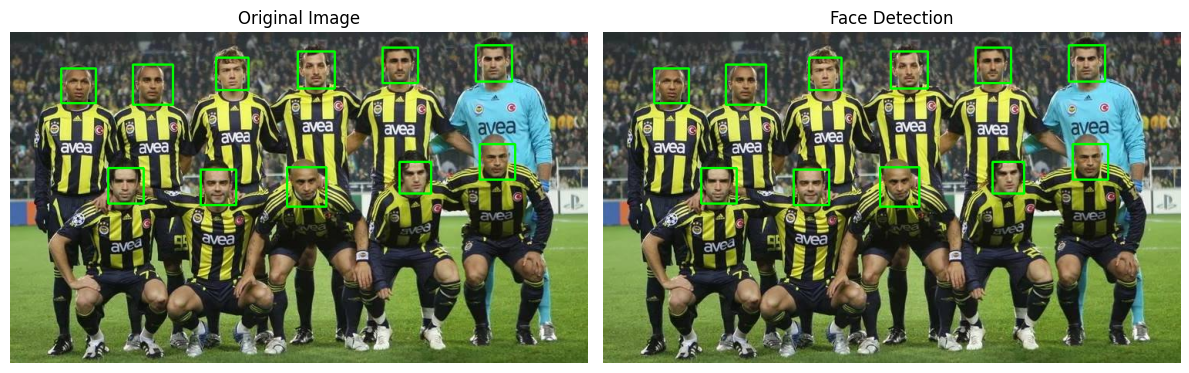

In [49]:
# Orijinal görüntüyü korumak için kopya oluştur
contoured_img = my_bgr_img.copy()

# Yüzlerin etrafına dikdörtgen çiz
for (x, y, w, h) in faces:
    cv2.rectangle(contoured_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Yan yana gösterim
plt.figure(figsize=(12,6))

# 1. subplot → Orijinal görüntü
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(my_bgr_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

# 2. subplot → Yüzleri dikdörtgenle çizilmiş görüntü
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(contoured_img, cv2.COLOR_BGR2RGB))
plt.title("Face Detection")
plt.axis('off')

plt.tight_layout()
plt.show()

In [50]:
# ÖZET:

# - Haar Cascade, önceden eğitilmiş bir sınıflandırıcı modeldir.
#   Görüntüdeki belirli nesneleri (özellikle yüzleri) tespit etmek için kullanılır.
# - Görüntü hem renkli (BGR) hem de gri tonlamalı olarak okunabilir.
#   Yüz tespiti işlemleri genellikle gri tonlamalı görüntüler üzerinde yapılır.
# - cv2.CascadeClassifier() ile Haar Cascade modeli yüklenir.
#   - Model: "haarcascade_frontalface_default.xml"
#   - Bu dosya, OpenCV’nin hazır yüz tespit modeli dizininde yer alır.
# - detectMultiScale() fonksiyonu, gri görüntü üzerinde yüzleri otomatik olarak algılar.
#   - scaleFactor → görüntüde farklı ölçeklerde yüz aramak için kullanılır.
#   - minNeighbors → bir bölgenin yüz olarak kabul edilmesi için gerekli komşu sayısı.
#   - minSize → algılanacak en küçük yüz boyutu (piksel cinsinden).
# - Her tespit edilen yüz, cv2.rectangle() fonksiyonu ile yeşil dikdörtgen içine alınır.
#   - (0,255,0) → yeşil renk kodu (BGR formatında)
#   - 2 → dikdörtgen kalınlığı
# - cv2.imshow() ile sonuç görüntüsü ekranda gösterilir.
#   cv2.waitKey(0) → tuş basılana kadar pencere açık kalır.
#   cv2.destroyAllWindows() → tüm pencereler kapatılır.
# - Bu konu, bilgisayarla görme (Computer Vision) alanında yüz tespiti,
#   nesne algılama ve görsel analiz gibi temel uygulamaların temelini oluşturur.
# - Kullanım alanları:
#   - Güvenlik sistemlerinde yüz tanıma
#   - Canlı kamera görüntülerinde yüz algılama
#   - Görsel veri analizi ve yapay zeka projeleri
